# Step 2: Data Preparation

In this step, we will **harmonize the labels** from both the **Davidson** and **Jigsaw Toxic Comment Classification** datasets. Harmonizing labels ensures consistency across datasets, which is crucial for effective model training and evaluation.

In [ ]:
# Import Necessary Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.utils import resample

# Optional: Display plots inline
%matplotlib inline

## 1. Load Data

Specify path to your csv files.

In [ ]:
# Define paths to your datasets
davidson_path = os.path.join('..', 'data', 'raw_data', 'labeled_data.csv')
jigsaw_path = os.path.join('..', 'data', 'raw_data', 'train.csv')  # Replace 'train.csv' with your Jigsaw file name if different

df_davidson = pd.read_csv(davidson_path)
df_jigsaw = pd.read_csv(jigsaw_path)

## 2. Define Unified Label Categories

We'll establish three primary categories to unify the labels from both datasets:

1. **Neutral**: Comments that are neither offensive nor hate speech.
2. **Offensive**: Comments that contain offensive language but are not directed at a specific group.
3. **Hate Speech**: Comments that contain hate speech, often directed at a specific group.


In [ ]:
# Mapping function for Davidson dataset
def map_davidson_label(label):
    if label == 0:
        return 'hate_speech'
    elif label == 1:
        return 'offensive'
    elif label == 2:
        return 'neutral'
    else:
        return 'unknown'

# Mapping function for Jigsaw dataset
def map_jigsaw_label(row):
    if row['identity_hate'] == 1 or row['severe_toxic'] == 1:
        return 'hate_speech'
    elif row['toxic'] == 1 or row['obscene'] == 1 or row['threat'] == 1 or row['insult'] == 1:
        return 'offensive'
    else:
        return 'neutral'

## 3. Apply Mapping Functions to Both Datasets

Transform the original labels using the mapping functions to align with our unified label scheme.


In [ ]:
# Process Davidson dataset
df_davidson = df_davidson[['class', 'tweet']].rename(columns={'class': 'label', 'tweet': 'text'})
df_davidson['label'] = df_davidson['label'].apply(map_davidson_label)
df_davidson['dataset'] = 'davidson'

# Process Jigsaw dataset
df_jigsaw['label'] = df_jigsaw.apply(map_jigsaw_label, axis=1)
df_jigsaw = df_jigsaw[['label', 'comment_text']].rename(columns={'comment_text': 'text'})
df_jigsaw['dataset'] = 'jigsaw'


Davidson Dataset - Mapped Labels:
label
offensive      19190
neutral         4163
hate_speech     1430
Name: count, dtype: int64


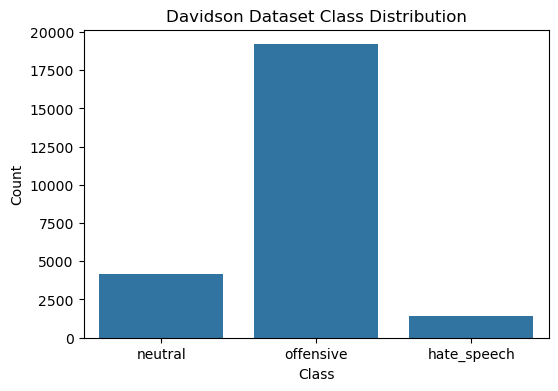


Jigsaw Dataset - Mapped Labels:
label
neutral        143346
offensive       13538
hate_speech      2687
Name: count, dtype: int64


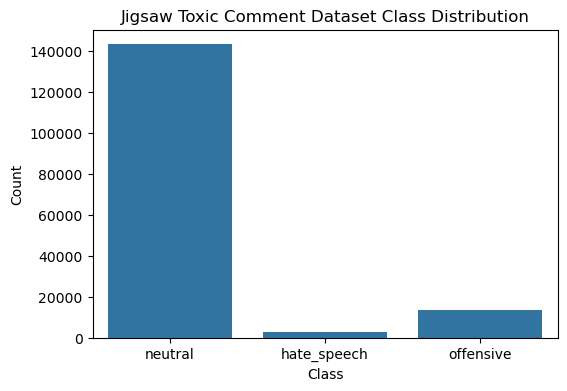

In [ ]:
# Verify Davidson dataset label distribution after mapping
print("Davidson Dataset - Mapped Labels:")
print(df_davidson['label'].value_counts())

# Plot class distribution for Davidson dataset
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_davidson)
plt.title('Davidson Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Verify Jigsaw dataset label distribution after mapping
print("\nJigsaw Dataset - Mapped Labels:")
print(df_jigsaw['label'].value_counts())

# Plot class distribution for Jigsaw dataset
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_jigsaw)
plt.title('Jigsaw Toxic Comment Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()